# Final modelling: rooftop PV and NSW demand

**Week 4 · 22 September 2026**

This workbook follows the [week 4 plan](week_4_modelling_plan.md), building on the
[week 3 findings](week_3_modelling_notes.md). It keeps two questions separate:

- **Association:** how does current demand change relate to current PV change?
- **Forecasting:** does observed PV help predict the next half-hour's demand change?

The models are ordinary least squares (OLS) and one fixed gradient-boosted tree
specification. All changes and errors are in **MW**, not MWh.

The August 2026 holdouts were already used in week 3. They are excluded here.
The seasonal checks below are development validation, not an untouched final test.
Run all cells from `src/` or the repository root using the existing project environment.
Results are summarised in [final_modelling_notes.md](final_modelling_notes.md).

## 1. Load and check the data

Use the supplied NSW1 data without changing its clock or filling demand/PV gaps.
The preparation script joins weather by calendar date. Time-zone conventions,
weather observation days, publication times and PV quality definitions still need
confirmation. Sydney weather is a local proxy, used only in retrospective OLS.


This cell loads the data and checks that every half-hour timestamp is present once.
It then removes August 2026 because those results were already inspected in week 3.
August could still be used as a clearly labelled comparison, but not as an independent final test because we already know its earlier results.
Keeping it out is a transparency decision, not a claim that August comparisons are invalid.
It also creates the folder used for the charts.

In [1]:
# Load the existing modelling packages.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display

# Keep all outputs beside this notebook.
ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
PLOTS = ROOT / 'src' / 'week_4_plots'
PLOTS.mkdir(exist_ok=True)
raw = pd.read_csv(ROOT / 'data' / 'NSW1_Historical_Modelling_Dataset_Week3.csv', parse_dates=['DATETIME'])
raw = raw.set_index('DATETIME').sort_index()
assert not raw.index.has_duplicates and not raw.index.hasnans

# Exclude August before deriving model inputs.
columns = {'OPERATIONAL_DEMAND_MW': 'demand', 'ROOFTOP_PV_MW': 'pv',
           'MAX_TEMP_C': 'temperature', 'SOLAR_EXPOSURE_MJ_M2': 'solar'}
data = raw.loc[raw.index < '2026-08-01', list(columns)].rename(columns=columns).copy()
assert data.index.equals(pd.date_range(data.index.min(), data.index.max(), freq='30min'))
print(f'{len(data):,} half-hours: {data.index.min()} to {data.index.max()}')
display(data.isna().sum().to_frame('Missing rows'))


def save_plot(figure, name):
    # Save the figure shown in the workbook.
    figure.tight_layout()
    figure.savefig(PLOTS / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(figure)

17,520 half-hours: 2025-08-01 00:00:00 to 2026-07-31 23:30:00


,Missing rows
demand,0
pv,1
temperature,48
solar,0


## Interpretation

The data contains 17,520 half-hours from 1 August 2025 to 31 July 2026 after August is excluded.
Demand has no missing values, while PV and some weather fields have a small number of missing values.
The later cells do not fill missing demand or PV values.

## 2. Changes and chronological validation

Recalculate changes from the supplied levels. Missing PV changes also get a missing
ramp label, rather than the source's “No change” label. This correction stays in memory.

Training starts in August 2025 and expands before each **14-day** validation window:
1–14 November 2025, February 2026, May 2026 and July 2026. These dates were training
data in week 3, so they are not wholly unseen evidence. No random split is used.




This cell calculates how much demand and PV changed since the previous half-hour.
It also creates the simple calendar controls and sets four two-week validation periods.
A validation period is a later period used to check a model trained on earlier data.

In [2]:
# Rebuild current changes and the short histories used below.
data['demand_change'] = data['demand'].diff()
data['pv_change'] = data['pv'].diff()
data['pv_lag'] = data['pv_change'].shift(1)
data['demand_lag'] = data['demand_change'].shift(1)
data['pv_direction'] = np.select([data['pv_change'].gt(0), data['pv_change'].lt(0)],
                                  ['Increase', 'Decrease'], default='No change')
data['pv_direction'] = data['pv_direction'].where(data['pv_change'].notna())

# Fix the validation dates before fitting any models.
folds = {'Spring': '2025-11-01', 'Summer': '2026-02-01',
         'Autumn': '2026-05-01', 'Winter': '2026-07-01'}
display(pd.DataFrame({'Window starts': folds}))


def calendar_matrix(index):
    # Use half-hour, weekday and season controls, without duplicate calendar fields.
    seasons = {12: 'Summer', 1: 'Summer', 2: 'Summer', 3: 'Autumn', 4: 'Autumn',
               5: 'Autumn', 6: 'Winter', 7: 'Winter', 8: 'Winter',
               9: 'Spring', 10: 'Spring', 11: 'Spring'}
    fields = pd.DataFrame(index=index)
    fields['slot'] = pd.Categorical(index.hour * 2 + index.minute // 30, categories=range(48))
    fields['weekday'] = pd.Categorical(index.dayofweek, categories=range(7))
    fields['season'] = pd.Categorical(index.month.map(seasons), categories=['Winter', 'Spring', 'Summer', 'Autumn'])
    return sm.add_constant(pd.get_dummies(fields, drop_first=True, dtype=float), has_constant='add')


def score(actual, predicted):
    # Calculate both errors on the same observations.
    errors = np.asarray(actual) - np.asarray(predicted)
    assert len(errors) > 0 and np.isfinite(errors).all()
    return {'MAE': np.abs(errors).mean(), 'RMSE': np.sqrt(np.mean(errors ** 2))}

,Window starts
Spring,2025-11-01
Summer,2026-02-01
Autumn,2026-05-01
Winter,2026-07-01


The four validation periods cover spring, summer, autumn and winter. Using time order matters because
it avoids letting a model learn from information that happened after the forecast or comparison date.
The missing PV observation stays missing, including its derived change direction.

## 3. Simple explanatory regressions

Predict **current** demand change from current PV change, calendar controls, maximum
temperature and daily solar exposure. Compare that base model with one extra PV-change
lag or one previous demand change. All three use the same rows.

Weather here describes the completed day; it is not a forecasting input. Replace
missing weather using training medians only. Select the diagnostic model by mean
validation MAE, then refit on pre-August data. The final PV intervals use HAC errors
with 48 retained observations, roughly one day. They do not account for model selection.



This cell compares three simple regression models for the current demand change. A regression model
measures how one value relates to others while holding the listed controls steady. The models add either
one earlier PV change or one earlier demand change to the same base set of calendar and weather controls.

C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\177178166.py:24: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fitted = sm.OLS(training['demand_change'], X_train[columns]).fit()
C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\177178166.py:24: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fitted = sm.OLS(training['demand_change'], X_train[columns]).fit()
C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\177178166.py:24: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fitted = sm.OLS(training['demand_change'], X_train[columns]).fit()
C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\177178166.py:24: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fitted = sm.OLS(training['demand_change'], X_train[columns]).fit()
C:\Users\Orion\A

,MAE,RMSE
Model,,
Add demand history,73.65,98.02
Add one PV lag,93.17,122.99
Base OLS,93.59,123.29


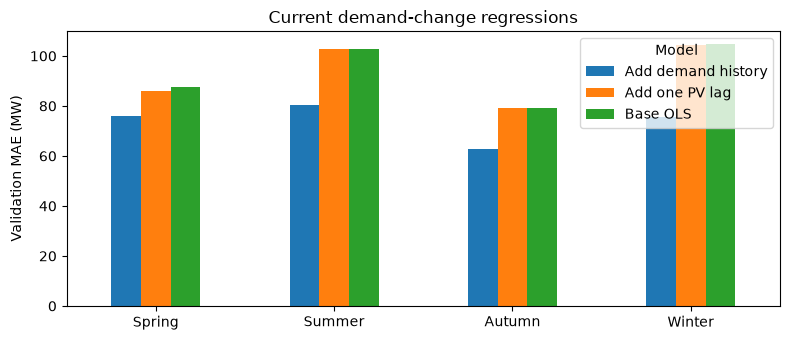

In [3]:
def explanatory_matrix(frame, training):
    # Fill weather from training only and retain the separate history terms.
    values = frame[['pv_change', 'temperature', 'solar', 'pv_lag', 'demand_lag']].copy()
    values[['temperature', 'solar']] = values[['temperature', 'solar']].fillna(training[['temperature', 'solar']].median())
    return pd.concat([calendar_matrix(frame.index), values], axis=1)


# Keep common rows for all three regressions.
explanatory = data.dropna(subset=['demand_change', 'pv_change', 'pv_lag', 'demand_lag'])
base = list(calendar_matrix(data.index[:1]).columns) + ['pv_change', 'temperature', 'solar']
specifications = {'Base OLS': base, 'Add one PV lag': base + ['pv_lag'],
                  'Add demand history': base + ['demand_lag']}
explanatory_rows = []

# Fit on earlier rows and score the next 14 days.
for fold, date in folds.items():
    start = pd.Timestamp(date)
    training = explanatory.loc[explanatory.index < start]
    validation = explanatory.loc[(explanatory.index >= start) & (explanatory.index < start + pd.Timedelta(days=14))]
    weather_training = data.loc[data.index < start]
    X_train = explanatory_matrix(training, weather_training)
    X_valid = explanatory_matrix(validation, weather_training)
    for name, columns in specifications.items():
        fitted = sm.OLS(training['demand_change'], X_train[columns]).fit()
        predicted = fitted.predict(X_valid[columns])
        explanatory_rows.append({'Window': fold, 'Model': name, **score(validation['demand_change'], predicted)})

# Compare average validation errors and keep the lowest-MAE specification.
explanatory_scores = pd.DataFrame(explanatory_rows)
explanatory_summary = explanatory_scores.groupby('Model')[['MAE', 'RMSE']].mean().sort_values(['MAE', 'RMSE'])
selected_ols = explanatory_summary.index[0]
display(explanatory_summary.round(2))
figure, axis = plt.subplots(figsize=(8, 3.5))
explanatory_scores.pivot(index='Window', columns='Model', values='MAE').reindex(folds).plot.bar(ax=axis, rot=0)
axis.set(ylabel='Validation MAE (MW)', xlabel='', title='Current demand-change regressions')
save_plot(figure, '01_explanatory_models.png')

### Interpretation

Adding one earlier PV change made very little difference: mean validation MAE fell from 93.59 MW to
93.17 MW. Adding one earlier demand change reduced it to 73.65 MW. MAE means the average size of the
model's errors, so lower values are better. Recent demand movement explained more of the remaining pattern than the extra PV lag.

## Refit

This cell refits the three regression models using all available pre-August data. It reports the PV
coefficient and a 95% interval. The interval shows a range of values consistent with the model and its
remaining time-based error pattern.

In [4]:
# Refit on pre-August data for descriptive PV coefficients.
X_explain = explanatory_matrix(explanatory, data)
final_fits = {}
coefficient_rows = []
for name, columns in specifications.items():
    fitted = sm.OLS(explanatory['demand_change'], X_explain[columns]).fit(
        cov_type='HAC', cov_kwds={'maxlags': 48})
    final_fits[name] = fitted
    lower, upper = fitted.conf_int().loc['pv_change']
    coefficient_rows.append({'Model': name, 'PV coefficient': fitted.params['pv_change'],
                             '95% lower': lower, '95% upper': upper})
coefficients = pd.DataFrame(coefficient_rows).set_index('Model')
display(coefficients.round(3))
print('Diagnostic model:', selected_ols, '| Common rows:', len(explanatory))

,PV coefficient,95% lower,95% upper
Model,,,
Base OLS,-0.737,-0.765,-0.709
Add one PV lag,-0.712,-0.745,-0.679
Add demand history,-0.474,-0.515,-0.432


Diagnostic model: Add demand history | Common rows: 17515


### Interpretation

The base model links a 100 MW increase in current PV change with about 73.7 MW less current demand
change, after its controls are included. Its 95% interval is about −76.5 to −70.9 MW per 100 MW PV change.
This is an association in this dataset, not proof that changing PV causes demand to change by that amount.

The base PV coefficient is a conditional association. Adding demand history changes
what is held fixed, so its PV slope answers a different question. Neither estimate is causal.

## 4. Next-half-hour forecasts

The row index below is the **target** time. Demand/PV inputs come from its origin,
30 minutes earlier, or older observations. This assumes origin observations are
already available; actual publication delays are unknown. These are rolling one-step
**pseudo-forecasts**, not an entire fortnight forecast at its start.

Compare OLS and a fixed tree, each with and without PV. Keep the week 3 tree settings:
100 iterations, 15 leaves, learning rate 0.08, minimum leaf size 30 and L2 penalty 1.
No parameter search or random early-stopping split is used.

Baselines predict zero change, yesterday's target-slot change or last week's
 target-slot change. They repeat **changes**, not demand levels. Every model uses
the same eligible targets, and observed weather is excluded.


This cell builds next-half-hour forecasts. It uses only demand and PV observations from the previous
half-hour or earlier, plus the target time's calendar fields. It compares simple historical baselines,
OLS regression and a fixed tree model. A tree model learns a set of if–then splits from the training data.

In [5]:
# Shift observations back from the target to the forecast origin.
forecast = pd.DataFrame(index=data.index)
forecast['actual'] = data['demand_change']
forecast['demand'] = data['demand'].shift(1)
forecast['demand_change'] = data['demand_change'].shift(1)
forecast['previous_change'] = data['demand_change'].shift(2)
forecast['demand_yesterday'] = data['demand'].shift(49)
forecast['pv'] = data['pv'].shift(1)
forecast['pv_change'] = data['pv_change'].shift(1)
forecast['previous_pv_change'] = data['pv_change'].shift(2)

# Add seasonal-change baselines and remove unavailable starting histories.
forecast['Previous day'] = data['demand_change'].shift(48)
forecast['Previous week'] = data['demand_change'].shift(336)
forecast = forecast.dropna()
non_pv = ['demand', 'demand_change', 'previous_change', 'demand_yesterday']
pv_inputs = ['pv', 'pv_change', 'previous_pv_change']
records = []

# Train each model before its validation target window.
for fold, date in folds.items():
    start = pd.Timestamp(date)
    training = forecast.loc[forecast.index < start]
    validation = forecast.loc[(forecast.index >= start) & (forecast.index < start + pd.Timedelta(days=14))]
    assert training.index.max() < validation.index.min() and len(validation) == 672
    predictions = {'Zero change': np.zeros(len(validation)),
                   'Previous day': validation['Previous day'], 'Previous week': validation['Previous week']}

    # Compare matched models using the same fixed settings.
    for with_pv in [False, True]:
        label = 'with PV' if with_pv else 'without PV'
        columns = non_pv + (pv_inputs if with_pv else [])
        X_train = pd.concat([calendar_matrix(training.index), training[columns]], axis=1)
        X_valid = pd.concat([calendar_matrix(validation.index), validation[columns]], axis=1)
        ols = sm.OLS(training['actual'], X_train).fit()
        tree = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=15, learning_rate=0.08,
                    min_samples_leaf=30, l2_regularization=1, early_stopping=False, random_state=42)
        tree.fit(X_train, training['actual'])
        predictions[f'OLS {label}'] = ols.predict(X_valid)
        predictions[f'Tree {label}'] = tree.predict(X_valid)

    # Retain paired predictions for the later error and subgroup checks.
    for name, predicted in predictions.items():
        records.append(pd.DataFrame({'Target': validation.index, 'Window': fold, 'Model': name,
                                      'Actual': validation['actual'].to_numpy(), 'Prediction': np.asarray(predicted)}))
    print(f'{fold}: {len(training):,} training targets; {len(validation)} validation targets')
outputs = pd.concat(records, ignore_index=True)

C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\3945951337.py:35: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(training['actual'], X_train).fit()


C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\3945951337.py:35: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(training['actual'], X_train).fit()
C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\3945951337.py:35: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(training['actual'], X_train).fit()


Spring: 4,076 training targets; 672 validation targets


C:\Users\Orion\AppData\Local\Temp\ipykernel_39892\3945951337.py:35: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols = sm.OLS(training['actual'], X_train).fit()


Summer: 8,492 training targets; 672 validation targets


Autumn: 12,764 training targets; 672 validation targets


Winter: 15,692 training targets; 672 validation targets


### What the result means

Each model is trained only on observations before a validation window and then predicts the following
14 days. The models assume the prior half-hour's demand and PV were already available. The supplied data
does not confirm whether that timing is true in practice, so these are pseudo-forecasts rather than verified real-time forecasts.

### Combine Validation Widnows

This cell combines the four validation windows and calculates each forecast model's average errors.
It then creates a chart so I can compare the models with the simple zero-change,
previous-day and previous-week baselines.

,MAE,RMSE
Model,,
Tree with PV,73.83,106.75
Tree without PV,78.47,112.75
OLS without PV,81.85,116.74
OLS with PV,82.23,116.30
Previous day,111.12,170.94
Previous week,113.89,171.25
Zero change,209.85,265.61


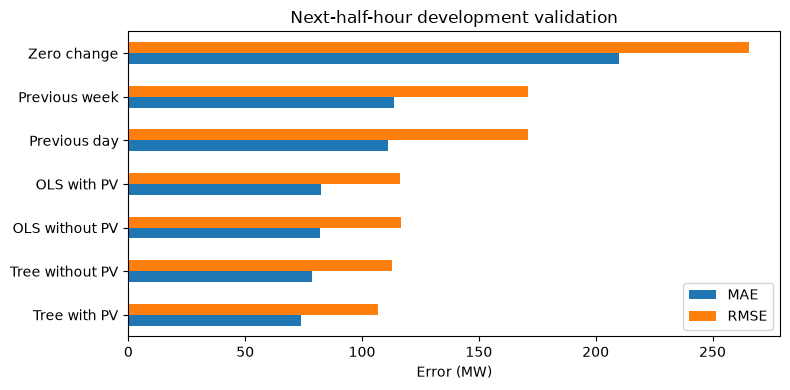

In [6]:
# Report pooled errors and keep the lowest-MAE model for the example plot.
forecast_summary = pd.DataFrame([{'Model': name, **score(group['Actual'], group['Prediction'])}
                                for name, group in outputs.groupby('Model')]).set_index('Model').sort_values(['MAE', 'RMSE'])
selected_forecast = forecast_summary.index[0]
display(forecast_summary.round(2))
figure, axis = plt.subplots(figsize=(8, 4))
forecast_summary[['MAE', 'RMSE']].plot.barh(ax=axis)
axis.set(xlabel='Error (MW)', ylabel='', title='Next-half-hour development validation')
save_plot(figure, '02_forecast_errors.png')

### Interpretation

The tree with PV has the lowest average error: MAE 73.83 MW and RMSE 106.75 MW. RMSE gives more weight
to large errors. The tree without PV has MAE 78.47 MW. OLS did not improve when PV was added, so the value of PV depends on the model used.

## GAM Comparison

This cell adds one fixed GAM forecast with PV to the same four validation windows.
A GAM, or generalised additive model, can fit smooth curved relationships instead of
assuming every input has a straight-line relationship with the forecast. I use the
same demand, PV and calendar inputs as the existing PV forecast models. Its settings
are fixed from the Week 3 approach, so I do not search for the best-looking result.

,MAE,RMSE
Model,,
Tree with PV,73.83,106.75
GAM with PV,78.17,110.00
Tree without PV,78.47,112.75
OLS without PV,81.85,116.74
OLS with PV,82.23,116.30
Previous day,111.12,170.94
Previous week,113.89,171.25
Zero change,209.85,265.61


GAM rows outside the matching training range: 25 of 2688


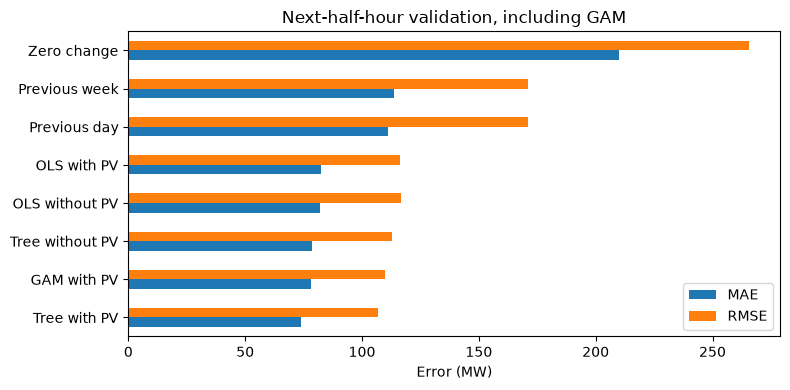

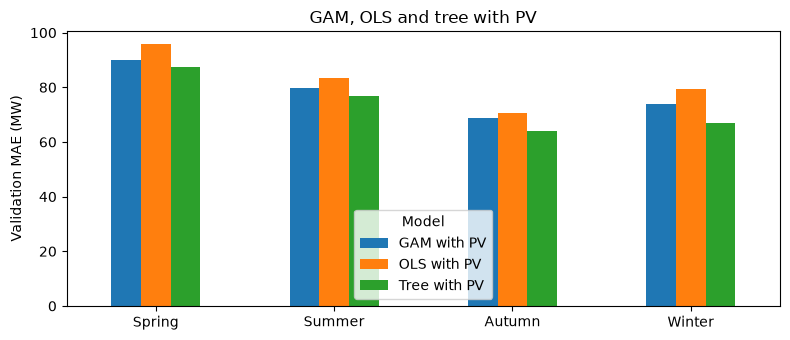

In [7]:
# Fit one fixed GAM with PV on the same chronological windows.
from statsmodels.gam.api import GLMGam, BSplines

gam_records = []
for fold, date in folds.items():
    start = pd.Timestamp(date)
    training = forecast.loc[forecast.index < start]
    validation = forecast.loc[(forecast.index >= start) & (forecast.index < start + pd.Timedelta(days=14))]
    inputs = non_pv + pv_inputs

    # Scale the smooth inputs using the earlier training data only.
    lower = training[inputs].min()
    span = (training[inputs].max() - lower).replace(0, 1)
    train_smooth = (training[inputs] - lower) / span
    valid_smooth = (validation[inputs] - lower) / span
    splines = BSplines(train_smooth, df=[6] * len(inputs), degree=[3] * len(inputs))

    # Keep calendar effects linear and use the fixed Week 3 smoothing penalty.
    gam = GLMGam(training['actual'], exog=calendar_matrix(training.index), smoother=splines,
                 alpha=[0.1] * len(inputs), family=sm.families.Gaussian()).fit()
    predicted = gam.predict(exog=calendar_matrix(validation.index), exog_smooth=valid_smooth.clip(0, 1))
    gam_records.append(pd.DataFrame({'Window': fold, 'Actual': validation['actual'].to_numpy(),
                                     'Prediction': np.asarray(predicted),
                                     'Outside training range': ((valid_smooth < 0) | (valid_smooth > 1)).any(axis=1).to_numpy()}))

gam_outputs = pd.concat(gam_records, ignore_index=True)
gam_result = pd.DataFrame([{'Model': 'GAM with PV', **score(gam_outputs['Actual'], gam_outputs['Prediction'])}]).set_index('Model')
comparison_with_gam = pd.concat([forecast_summary, gam_result]).sort_values(['MAE', 'RMSE'])
display(comparison_with_gam.round(2))
print('GAM rows outside the matching training range:', gam_outputs['Outside training range'].sum(), 'of', len(gam_outputs))

# Plot the overall GAM comparison beside every existing forecast model.
figure, axis = plt.subplots(figsize=(8, 4))
comparison_with_gam[['MAE', 'RMSE']].plot.barh(ax=axis)
axis.set(xlabel='Error (MW)', ylabel='', title='Next-half-hour validation, including GAM')
save_plot(figure, '07_forecast_errors_with_gam.png')

# Compare the GAM with the PV versions of OLS and the tree in each window.
gam_by_window = pd.DataFrame([{'Window': window, 'Model': 'GAM with PV', **score(group['Actual'], group['Prediction'])}
                              for window, group in gam_outputs.groupby('Window')])
benchmarks = outputs.loc[outputs['Model'].isin(['OLS with PV', 'Tree with PV'])]
benchmark_by_window = pd.DataFrame([{'Window': window, 'Model': model, **score(group['Actual'], group['Prediction'])}
                                    for (window, model), group in benchmarks.groupby(['Window', 'Model'])])
window_comparison = pd.concat([benchmark_by_window, gam_by_window])
figure, axis = plt.subplots(figsize=(8, 3.5))
window_comparison.pivot(index='Window', columns='Model', values='MAE').reindex(folds).plot.bar(ax=axis, rot=0)
axis.set(ylabel='Validation MAE (MW)', xlabel='', title='GAM, OLS and tree with PV')
save_plot(figure, '08_gam_by_window.png')

### Interpretation

The first chart compares the GAM with every forecast model, while the second compares the GAM, OLS and tree with PV in each validation window. The fixed GAM with PV has MAE 78.17 MW and RMSE 110.00 MW. It performs better than both OLS models, but not as well as the tree with PV, which has MAE 73.83 MW. The GAM result is a model comparison, not evidence that PV has a causal effect. Twenty-five validation rows are clipped to the earlier training range, so the GAM is not asked to extrapolate beyond what it has seen.

## 5. Where PV helps the tree

Pair tree errors on the same targets. Positive **MAE gain** means that adding PV
helped. Compare season windows and source-clock periods; 06–18 is not a verified
astronomical daylight definition.

For uncertainty, resample whole days within each window 2,000 times. This keeps
half-hours and PV/non-PV errors paired within a day. The resulting interval does
not cover dependence between days or the choice of model using these validation data.



This cell compares the two tree forecasts for the exact same target times. It checks whether adding PV
reduces error in each seasonal window and time-of-day group. It also resamples full days 2,000 times to
show how much the estimated PV improvement varies from day to day.

,mean,size
Window,,
Autumn,2.21,672
Spring,4.94,672
Summer,7.14,672
Winter,4.28,672


,mean,size
Period,,
00–06,0.20,672
06–12,14.46,672
12–18,1.48,672
18–24,2.43,672


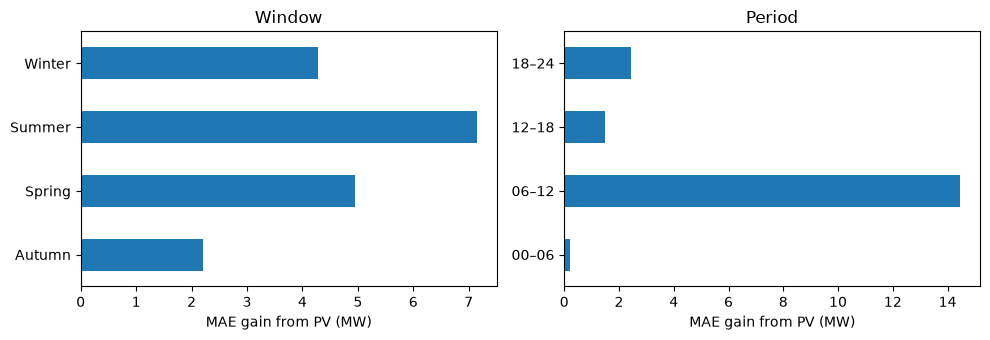

Tree MAE gain: 4.64 MW; daily-bootstrap 95% interval: 3.22 to 6.02 MW


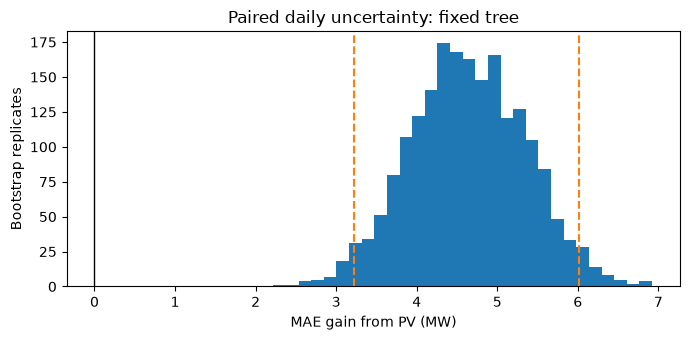

In [8]:
# Pair PV and non-PV tree predictions before comparing their errors.
tree_outputs = outputs.loc[outputs['Model'].str.startswith('Tree')]
paired = tree_outputs.pivot(index=['Target', 'Window'], columns='Model', values='Prediction')
actual = tree_outputs.groupby(['Target', 'Window'])['Actual'].first()
paired['Gain MW'] = (actual - paired['Tree without PV']).abs() - (actual - paired['Tree with PV']).abs()
paired = paired.reset_index()
paired['Period'] = pd.cut(paired['Target'].dt.hour, [0, 6, 12, 18, 24], right=False,
                          labels=['00–06', '06–12', '12–18', '18–24'])

# Show the gain by season window and time of day.
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for axis, column in zip(axes, ['Window', 'Period']):
    summary = paired.groupby(column, observed=True)['Gain MW'].agg(['mean', 'size'])
    display(summary.round(2))
    summary['mean'].plot.barh(ax=axis)
    axis.axvline(0, color='grey', linewidth=0.8)
    axis.set(xlabel='MAE gain from PV (MW)', ylabel='', title=column)
save_plot(figure, '03_pv_gain_by_group.png')

# Resample paired daily gains within each of the four windows.
daily_gain = paired.groupby(['Window', paired['Target'].dt.normalize()])['Gain MW'].mean()
rng = np.random.default_rng(42)
bootstrap = np.zeros(2000)
for fold in folds:
    days = daily_gain.loc[fold].to_numpy()
    bootstrap += rng.choice(days, size=(2000, len(days)), replace=True).mean(axis=1) / len(folds)
pv_gain = paired['Gain MW'].mean()
lower_gain, upper_gain = np.quantile(bootstrap, [0.025, 0.975])
print(f'Tree MAE gain: {pv_gain:.2f} MW; daily-bootstrap 95% interval: {lower_gain:.2f} to {upper_gain:.2f} MW')

# Mark zero gain and the bootstrap interval on the distribution.
figure, axis = plt.subplots(figsize=(7, 3.5))
axis.hist(bootstrap, bins=30)
axis.axvline(0, color='black', linewidth=1)
for bound in [lower_gain, upper_gain]:
    axis.axvline(bound, color='tab:orange', linestyle='--')
axis.set(xlabel='MAE gain from PV (MW)', ylabel='Bootstrap replicates', title='Paired daily uncertainty: fixed tree')
save_plot(figure, '04_daily_uncertainty.png')


Adding PV reduced the tree's average error by 4.64 MW. The daily resampling interval is 3.22 to 6.02 MW,
which suggests a positive improvement in these four validation windows. This interval does not prove the
same result will occur in future years or account for the earlier choice of this model.

## 6. Residual check and forecast example

Check whether the selected explanatory OLS still leaves serial dependence. Reinsert
excluded timestamps before calculating correlations. HAC intervals allow for some
residual dependence; they do not remove it.

The forecast example uses the fixed dates 1–2 July, rather than choosing unusually
good predictions after seeing the errors.


This cell checks the unexplained part of the regression model, called the residual. It measures whether
nearby residuals still look alike over time, then plots the selected forecast for two fixed winter days.
The dates were fixed before viewing this chart.

,Model,Lag half-hours,Correlation
0,Base OLS,1,0.683
1,Base OLS,2,0.491
2,Base OLS,48,0.625
3,Add demand history,1,0.193
4,Add demand history,2,0.151
5,Add demand history,48,0.425


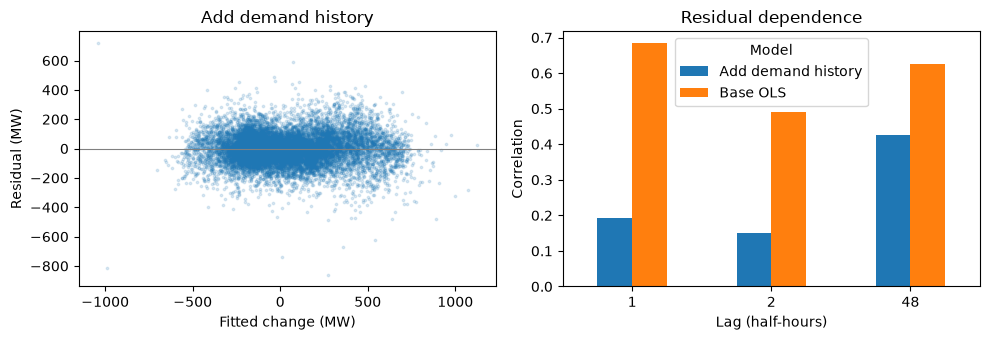

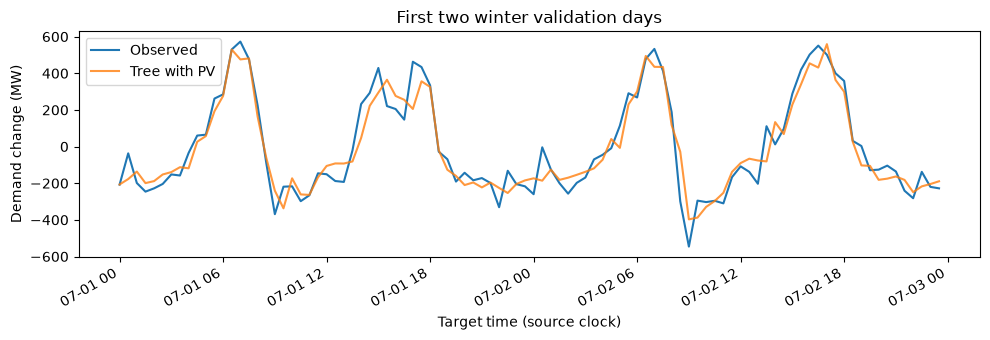

In [9]:
# Compare the base and selected OLS residuals on the original clock grid.
residual_rows = []
for name in dict.fromkeys(['Base OLS', selected_ols]):
    residual = final_fits[name].resid.reindex(data.index)
    for lag in [1, 2, 48]:
        residual_rows.append({'Model': name, 'Lag half-hours': lag, 'Correlation': residual.corr(residual.shift(lag))})
residual_table = pd.DataFrame(residual_rows)
display(residual_table.round(3))

# Inspect residual spread and remaining serial correlation.
fitted = final_fits[selected_ols]
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(fitted.fittedvalues, fitted.resid, s=3, alpha=0.15)
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].set(xlabel='Fitted change (MW)', ylabel='Residual (MW)', title=selected_ols)
residual_table.pivot(index='Lag half-hours', columns='Model', values='Correlation').plot.bar(ax=axes[1], rot=0)
axes[1].set(xlabel='Lag (half-hours)', ylabel='Correlation', title='Residual dependence')
save_plot(figure, '05_residual_checks.png')

# Plot the selected forecast against observations on two fixed validation days.
example = outputs.loc[outputs['Model'].eq(selected_forecast) & outputs['Target'].ge('2026-07-01')
                      & outputs['Target'].lt('2026-07-03')]
figure, axis = plt.subplots(figsize=(10, 3.5))
axis.plot(example['Target'], example['Actual'], label='Observed')
axis.plot(example['Target'], example['Prediction'], label=selected_forecast, alpha=0.8)
axis.set(xlabel='Target time (source clock)', ylabel='Demand change (MW)', title='First two winter validation days')
axis.legend()
figure.autofmt_xdate()
save_plot(figure, '06_forecast_example.png')

### Interpretation

Adding demand history reduces the 30-minute residual correlation from 0.683 to 0.193, but the one-day
correlation is still 0.425. The model therefore still misses some regular demand patterns. The two-day chart is an example of model behaviour, not evidence on its own that the model will work in every period.

## 7. What these results can support

Use the OLS coefficients as **conditional associations**, and forecast errors as
**development-validation comparisons**. The four windows cover different seasons,
but each is short and none is a genuinely new final test. The model with the lowest
validation error still needs testing on newly collected observations.

The fixed GAM with PV is included as a simple comparison. It performs better than
both OLS forecasts, but the tree with PV remains the lowest-error model. This version
still leaves out parameter searches, large interaction models and multiple
covariance, quality and delay sensitivity runs. It keeps the core Week 4 comparisons
readable; it does not claim to complete every proposed experiment.

Further work needs confirmed AEMO/BoM timing and PV quality definitions, actual
publication delays, broader aligned weather or issued weather forecasts, and new
demand/PV data. An AEMO benchmark also needs matching issue times and horizons.
These inputs are unavailable here and are not replaced with invented values.

### Sources

- Statsmodels developers n.d., *RegressionResults.get_robustcov_results*, viewed
  22 September 2026,
  <https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html>.
- Scikit-learn developers n.d., *HistGradientBoostingRegressor*, viewed 22 September
  2026, <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html>.